# Credit Score Classification

# 1. Business Understanding

Financial institutions need to assess customer credit risk using financial information and credit-payment history. This project develops a machine learning model that predicts a customer's credit score category.

## Project Objective

Identify data-quality issues and missing values.
Explore relationships between customer characteristics and credit score.
Build a leakage-safe preprocessing workflow.
Compare multiple classification algorithms.
Evaluate the selected model on an unseen test set.
Interpret the model using feature importance.


target variable :
y = credit score

jenis masalah 🇰
multi class classification


## 2. Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from scipy.sparse import hstack

## 3. Load and Inspect Data

In [ ]:
df = pd.read_csv('data_D.csv')

print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

df.head()

Jumlah Baris : 25000
Jumlah Kolom : 29


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22471 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21173 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,25000.0,NaN,NaN,NaN,12499.5,7217.022701,0.0,6249.75,12499.5,18749.25,24999.0
ID,25000,25000,0x10d0c,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,25000,11199,CUS_0x8727,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,25000,8,August,3189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,22471,9014,Deepa Seetharamanm,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,25000,548,27,708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,25000,11024,#F%$D@*&8,1397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,25000,16,_______,1735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,25000,12749,29020.78,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Inhand_Salary,21173.0,NaN,NaN,NaN,4168.307097,3170.867622,303.645417,1625.265833,3080.353333,5927.5275,15204.633333


In [ ]:
df.shape

(25000, 29)

### Initial observations

The dataset contains customer-level financial and credit-history information. Before modeling, we check missing values, duplicates, target distribution, data types, and potentially invalid numeric values.

## 4. Exploratory Data Analysis

In [ ]:
# Check missing value
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round(df.isnull().mean()*100,2)
})

missing = missing[missing['Missing Count']>0]
missing.sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
Monthly_Inhand_Salary,3827,15.31
Type_of_Loan,2880,11.52
Name,2529,10.12
Credit_History_Age,2249,9.00
Num_of_Delayed_Payment,1744,6.98
Amount_invested_monthly,1121,4.48
Num_Credit_Inquiries,497,1.99
Monthly_Balance,309,1.24


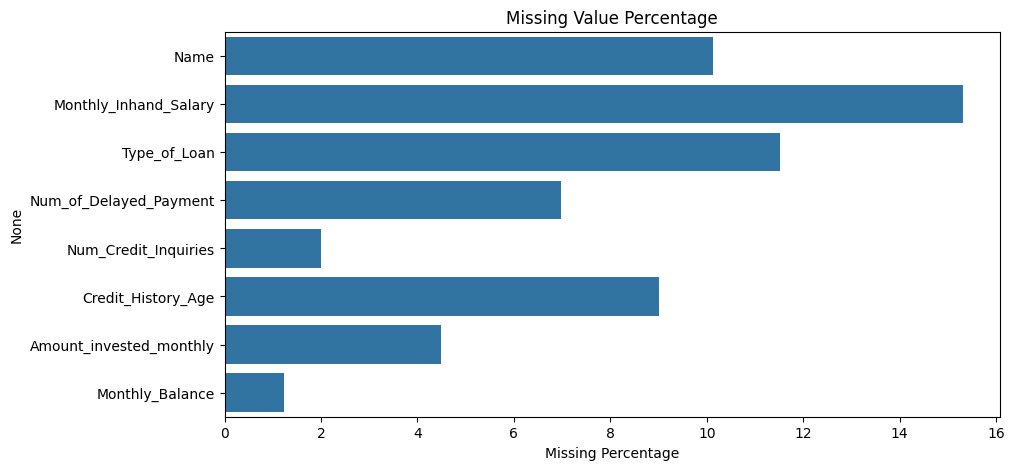

In [ ]:
# Visualisasi missing values
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing['Missing Percentage'],
    y=missing.index
)

plt.title('Missing Value Percentage')
plt.show()

Beberapa fitur memiliki missing value cukup tinggi seperti Monthly_Inhand_Salary (15.31%), Type_of_Loan (11.52%), dan Credit_History_Age (9.00%). Oleh karena itu diperlukan proses imputasi pada tahap preprocessing dan setelah split data.

In [ ]:
# Check duplicates
print("Jumlah Duplikasi :", df.duplicated().sum())

Jumlah Duplikasi : 0


In [ ]:
# Check target y = credit_score
df['Credit_Score'].value_counts()


,count
Credit_Score,
Standard,13305
Poor,7231
Good,4464


### Feature Groups

In [ ]:
# cek isi kolom
df.columns

In [ ]:
# Numerical features
num = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

# cateorical features
obj = [
    'Month',
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Credit_History_Age',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]


In [ ]:
# Melihat kesalahan tipe data
for col in num:
    print(f"\n{col}")
    print(df[col].head(10))


Age
0    32
1    39
2    45
3    32
4    18
5    28
6    30
7    37
8    25
9    21
Name: Age, dtype: object

Annual_Income
0      56125.5
1      62148.0
2     88380.16
3      7821.24
4     107871.9
5     79950.34
6     16154.25
7     62683.59
8    112882.68
9     88463.25
Name: Annual_Income, dtype: object

Monthly_Inhand_Salary
0    4875.125000
1            NaN
2    7471.013333
3     468.770000
4            NaN
5    6393.528333
6    1273.187500
7    5047.632500
8    9684.890000
9    7609.937500
Name: Monthly_Inhand_Salary, dtype: float64

Num_Bank_Accounts
0    8
1    9
2    7
3    8
4    3
5    3
6    8
7    8
8    5
9    5
Name: Num_Bank_Accounts, dtype: int64

Num_Credit_Card
0     3
1     7
2     7
3    10
4     4
5     1
6     8
7     8
8     1
9     3
Name: Num_Credit_Card, dtype: int64

Interest_Rate
0    18
1    24
2    19
3    29
4     8
5    10
6    29
7    32
8    10
9     6
Name: Interest_Rate, dtype: int64

Num_of_Loan
0    2
1    5
2    3
3    6
4    3
5    4
6    5
7 

In [ ]:
# memperbaiki tipe data menjadi numerik
for col in num:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('_', '', regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [ ]:
df[num].dtypes

,0
Age,int64
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64
Num_Credit_Card,int64
Interest_Rate,int64
Num_of_Loan,int64
Delay_from_due_date,int64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64


In [ ]:
# Data quality check
for col in num:
    print(
        col,
        "MIN =", df[col].min(),
        "MAX =", df[col].max()
    )

Age MIN = -500 MAX = 8669
Annual_Income MIN = 7005.93 MAX = 24198062.0
Monthly_Inhand_Salary MIN = 303.6454166666666 MAX = 15204.633333333331
Num_Bank_Accounts MIN = -1 MAX = 1794
Num_Credit_Card MIN = 0 MAX = 1499
Interest_Rate MIN = 1 MAX = 5789
Num_of_Loan MIN = -100 MAX = 1485
Delay_from_due_date MIN = -5 MAX = 67
Num_of_Delayed_Payment MIN = -3.0 MAX = 4340.0
Changed_Credit_Limit MIN = -6.44 MAX = 36.97
Num_Credit_Inquiries MIN = 0.0 MAX = 2553.0
Outstanding_Debt MIN = 0.23 MAX = 4998.07
Credit_Utilization_Ratio MIN = 20.0 MAX = 49.56451934738699
Total_EMI_per_month MIN = 0.0 MAX = 82122.0
Amount_invested_monthly MIN = 0.0 MAX = 10000.0
Monthly_Balance MIN = -3.333333333333333e+26 MAX = 1602.0405189622518


Berdasarkan data quality check, ditemukan beberapa nilai yang tidak realistis secara bisnis seperti Age bernilai negatif atau ribuan tahun, jumlah kartu kredit sangat besar, interest rate sangat tinggi, dan Monthly_Balance dengan nilai ekstrem. Nilai seperti ini dikategorikan sebagai invalid value, bukan outlier normal.

In [ ]:
# Drop kolom kategorikal yang tidak berpengaruh langsung kepada y
drop_cols = [
    'Unnamed: 0',
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
]

df.drop(columns=drop_cols, inplace=True)

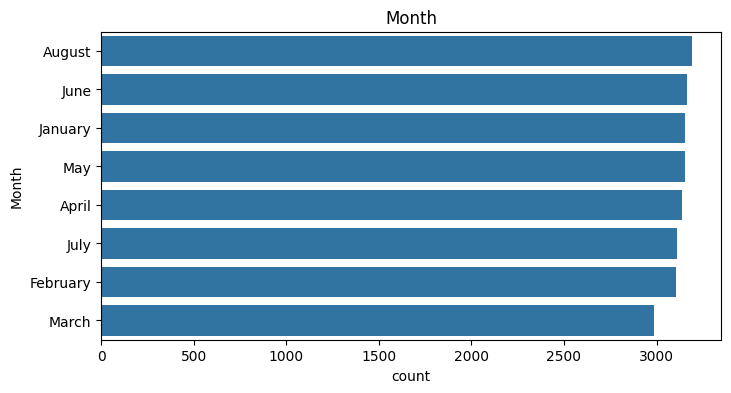

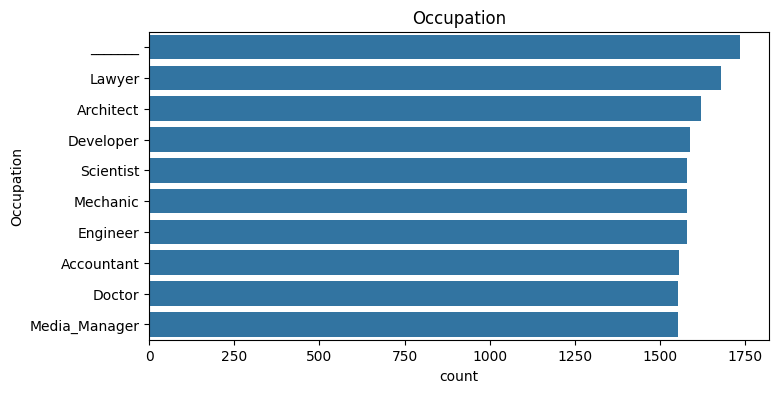

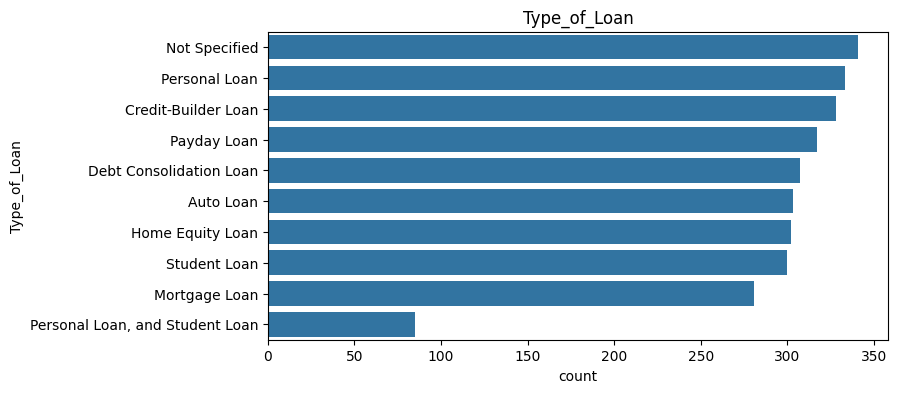

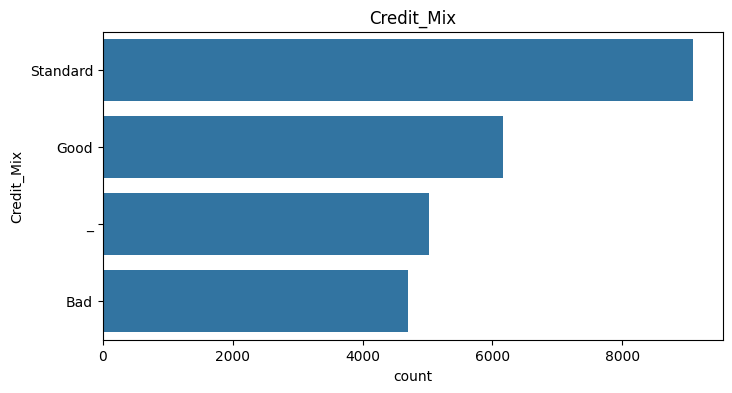

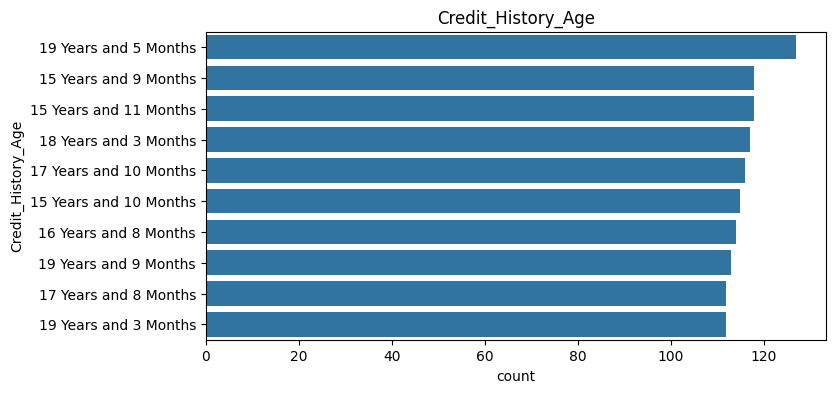

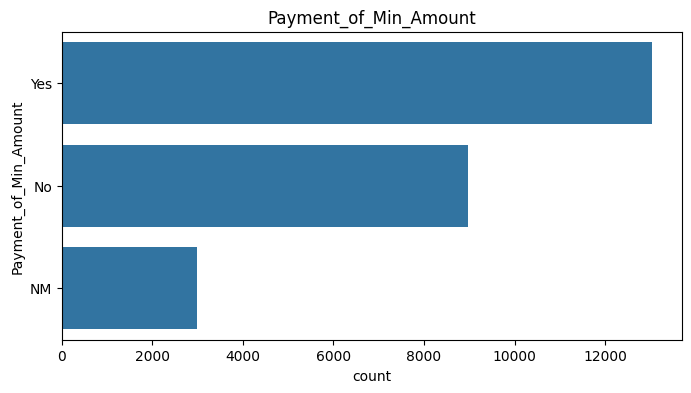

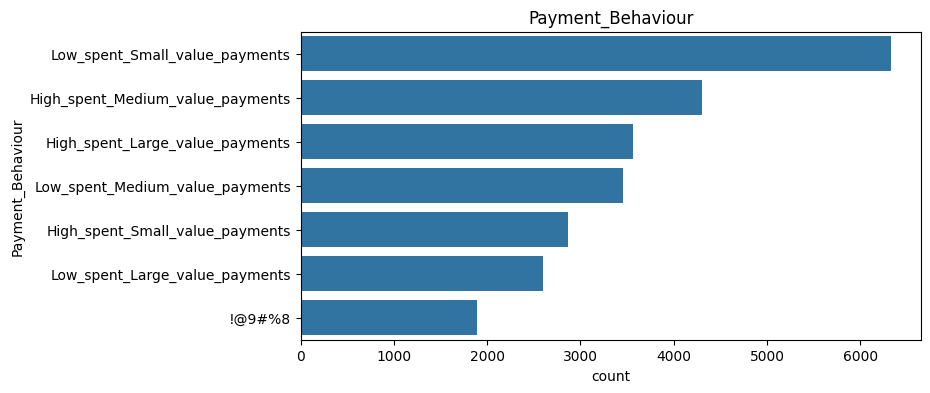

In [ ]:
# check outlier pada object
for col in obj:
    plt.figure(figsize=(8,4))

    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index[:10]
    )

    plt.title(col)
    plt.show()

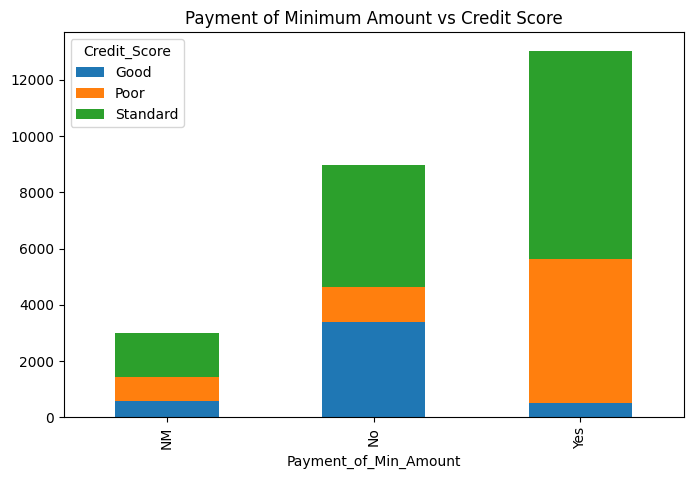

In [ ]:
pd.crosstab(
    df['Payment_of_Min_Amount'],
    df['Credit_Score']
).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Payment of Minimum Amount vs Credit Score')
plt.show()

Dari grafik terlihat bahwa kategori Yes memiliki jumlah pelanggan terbanyak, dan mayoritas di antaranya memiliki Credit Score Standard, diikuti Poor, sedangkan Good merupakan yang paling sedikit. Pada kategori No, jumlah pelanggan juga cukup banyak dan didominasi oleh Credit Score Standard, namun proporsi Good lebih tinggi dibandingkan kategori Yes. Sementara itu, kategori NM memiliki jumlah pelanggan paling sedikit, dengan sebagian besar juga berada pada Credit Score Standard.

Secara keseluruhan, Credit Score Standard mendominasi pada semua kategori pembayaran minimum, sedangkan Credit Score Good memiliki jumlah paling sedikit. Hal ini menunjukkan bahwa status pembayaran minimum saja belum dapat membedakan kualitas credit score secara jelas karena sebagian besar pelanggan tetap berada pada kategori Standard.

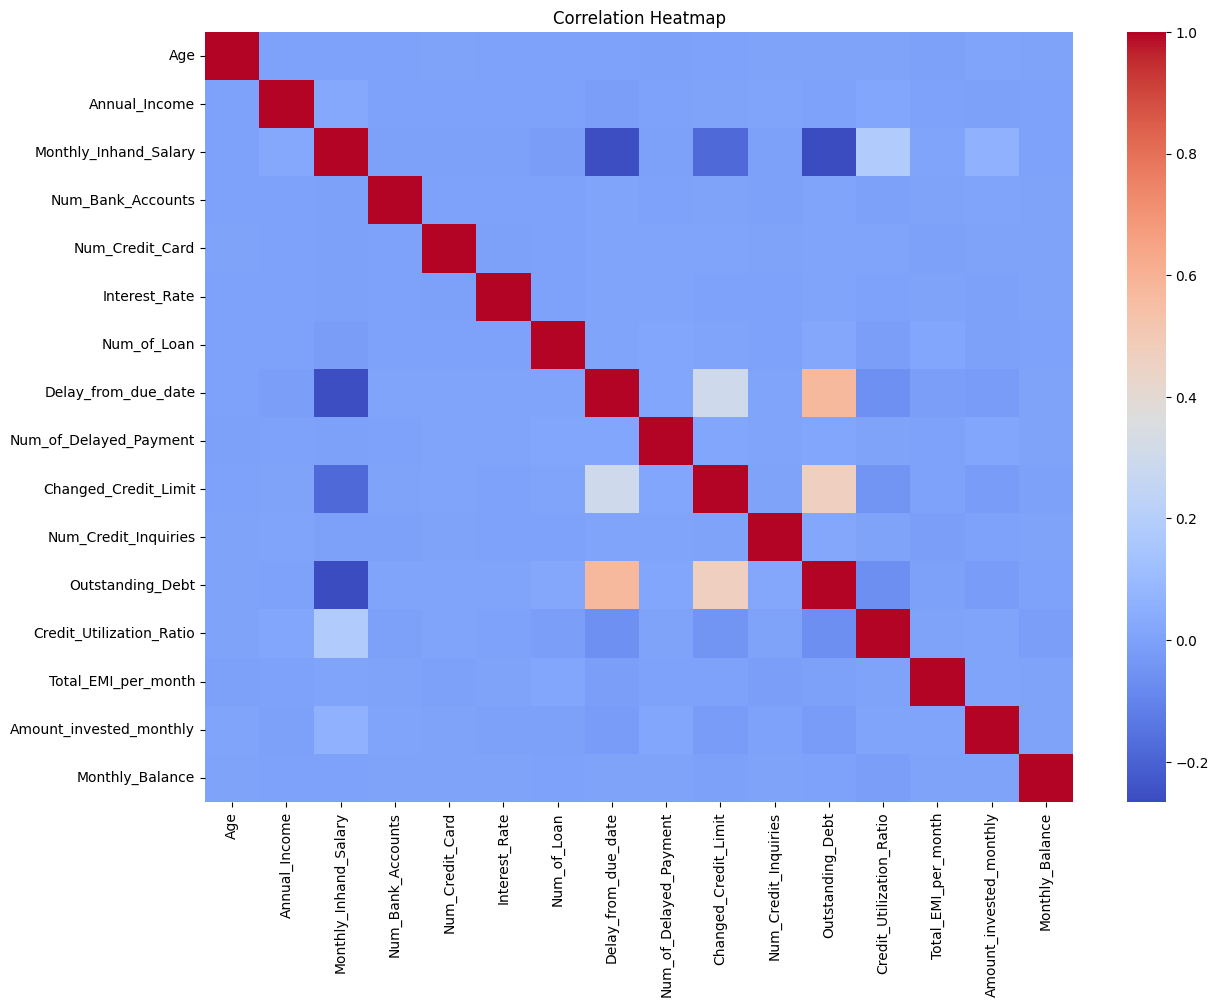

In [ ]:
# Correlation Analysis
plt.figure(figsize=(14,10))

sns.heatmap(
    df[num].corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

Correlation heatmap menunjukkan hubungan linear antar variabel numerik. Warna merah menunjukkan korelasi positif, artinya kedua variabel cenderung meningkat bersama, sedangkan warna biru menunjukkan korelasi negatif, artinya ketika satu variabel meningkat, variabel lainnya cenderung menurun. Semakin pekat warnanya, semakin kuat hubungan antarvariabel. Berdasarkan heatmap, sebagian besar variabel memiliki korelasi yang lemah karena didominasi warna biru muda, sehingga tidak terdapat hubungan yang sangat kuat antar fitur dan risiko multikolinearitas tergolong rendah.


# Train Test Split
Data dibagi terlebih dahulu menjadi training, validation, dan testing set. Setelah pembagian ini, proses data quality dan preprocessing dilakukan secara terpisah dengan parameter preprocessing dipelajari hanya dari training set.


In [ ]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [ ]:
# Karena value target itu Poor, Standard, Good, target akan di-encode setelah train-validation-test split.
print(y.value_counts())


In [ ]:
# Mmebagi train = 80 % test = 20 %
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Membagi test = 10 % val = 10 %
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)

Training Set : (20000, 23)
Validation Set : (2500, 23)
Testing Set : (2500, 23)


In [ ]:
print("Train :", len(X_train)/len(df)*100)
print("Validation :", len(X_val)/len(df)*100)
print("Test :", len(X_test)/len(df)*100)

Train : 80.0
Validation : 10.0
Test : 10.0


In [ ]:
# Encoding target y setelah train-validation-test split
target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_val = target_encoder.transform(y_val)
y_test = target_encoder.transform(y_test)


In [ ]:
print(pd.Series(y_train).value_counts(normalize=True))
print(pd.Series(y_val).value_counts(normalize=True))
print(pd.Series(y_test).value_counts(normalize=True))

2    0.53220
1    0.28925
0    0.17855
Name: proportion, dtype: float64
2    0.5324
1    0.2892
0    0.1784
Name: proportion, dtype: float64
2    0.5320
1    0.2892
0    0.1788
Name: proportion, dtype: float64


Dataset dibagi menjadi tiga bagian yaitu training set (80%), validation set (10%), dan testing set (10%). Training set digunakan untuk melatih model, validation set digunakan untuk memilih model terbaik selama eksperimen, sedangkan testing set digunakan sebagai evaluasi akhir terhadap model yang terpilih. Parameter stratify digunakan agar proporsi setiap kelas Credit_Score tetap terjaga pada ketiga subset data. Pembagian data dilakukan sebelum proses imputasi, data-quality correction, encoding fitur, dan scaling untuk menghindari data leakage.


## 7. Preprocessing Pipeline

In [ ]:
# Membuktikan inputasi mean atau median
for col in (num):

    print(col)
    print("Mean :", X_train[col].mean())
    print("Median :", X_train[col].median())
    print("-"*30)

Age
Mean : 111.4964
Median : 33.0
------------------------------
Annual_Income
Mean : 173761.996653
Median : 37360.94
------------------------------
Monthly_Inhand_Salary
Mean : 4176.297059380655
Median : 3081.9025
------------------------------
Num_Bank_Accounts
Mean : 16.8
Median : 6.0
------------------------------
Num_Credit_Card
Mean : 23.1944
Median : 6.0
------------------------------
Interest_Rate
Mean : 72.8052
Median : 13.0
------------------------------
Num_of_Loan
Mean : 2.9361
Median : 3.0
------------------------------
Delay_from_due_date
Mean : 21.00095
Median : 18.0
------------------------------
Num_of_Delayed_Payment
Mean : 29.83658444838519
Median : 14.0
------------------------------
Changed_Credit_Limit
Mean : 10.40722352820932
Median : 9.37
------------------------------
Num_Credit_Inquiries
Mean : 26.329558208346086
Median : 6.0
------------------------------
Outstanding_Debt
Mean : 1423.7688375
Median : 1156.9499999999998
------------------------------
Credit_Ut

Pemilihan median sebagai metode imputasi untuk fitur numerik didasarkan pada hasil analisis statistik deskriptif. Beberapa fitur seperti Annual_Income, Amount_invested_monthly, dan Monthly_Balance menunjukkan perbedaan yang sangat besar antara nilai mean dan median. Sebagai contoh, fitur Annual_Income memiliki mean sebesar 173,761 sedangkan median hanya sebesar 37,360. Selain itu, fitur Monthly_Balance memiliki mean sebesar -3.38 × 10²² yang jauh berbeda dengan median sebesar 337.93. Perbedaan yang signifikan ini mengindikasikan adanya outlier dan nilai ekstrem pada dataset. Oleh karena itu, median dipilih karena lebih robust terhadap outlier dibandingkan mean sehingga dapat menghasilkan imputasi yang lebih representatif terhadap distribusi data sebenarnya.

In [ ]:
# cek monthly balance
X_train['Monthly_Balance'].describe()

,Monthly_Balance
count,1.974800e+04
mean,-3.375869e+22
std,3.354449e+24
min,-3.333333e+26
25%,2.709268e+02
50%,3.379344e+02
75%,4.680752e+02
max,1.602041e+03


In [ ]:

(X_train['Monthly_Balance'] < -1e10).sum()

np.int64(2)

Pada fitur Monthly_Balance ditemukan dua observasi dengan nilai ekstrem sebesar -3.33 × 10²⁶. Nilai tersebut berada jauh di luar rentang distribusi data dan tidak realistis secara bisnis. Oleh karena itu kedua observasi tersebut dikategorikan sebagai data error dan diubah menjadi missing value (NaN) sebelum proses imputasi dilakukan.

## Data Quality

In [ ]:
# Data quality improvement
def handle_invalid_values(data):
    data = data.copy()

    data.loc[
        (data['Age'] < 18) | (data['Age'] > 100),
        'Age'
    ] = np.nan

    data.loc[
        data['Num_Bank_Accounts'] < 0,
        'Num_Bank_Accounts'
    ] = np.nan

    data.loc[
        data['Num_Credit_Card'] > 50,
        'Num_Credit_Card'
    ] = np.nan

    data.loc[
        data['Interest_Rate'] > 100,
        'Interest_Rate'
    ] = np.nan

    data.loc[
        (data['Num_of_Loan'] < 0) | (data['Num_of_Loan'] > 20),
        'Num_of_Loan'
    ] = np.nan

    data.loc[
        (data['Num_of_Delayed_Payment'] < 0) |
        (data['Num_of_Delayed_Payment'] > 100),
        'Num_of_Delayed_Payment'
    ] = np.nan

    data.loc[
        data['Num_Credit_Inquiries'] > 100,
        'Num_Credit_Inquiries'
    ] = np.nan

    data.loc[
        data['Monthly_Balance'] < -1e10,
        'Monthly_Balance'
    ] = np.nan

    return data

In [ ]:
X_train = handle_invalid_values(X_train)
X_val = handle_invalid_values(X_val)
X_test = handle_invalid_values(X_test)

In [ ]:
comparison = pd.DataFrame({
    'Mean': X_train[num].mean(),
    'Median': X_train[num].median()
})

comparison['Difference'] = abs(
    comparison['Mean'] - comparison['Median']
)

comparison.sort_values(
    'Difference',
    ascending=False
)

,Mean,Median,Difference
Annual_Income,173761.996653,37360.940000,136401.056653
Total_EMI_per_month,1426.366762,68.498987,1357.867775
Monthly_Inhand_Salary,4176.297059,3081.902500,1094.394559
Amount_invested_monthly,645.580248,133.426123,512.154125
Outstanding_Debt,1423.768838,1156.950000,266.818838
Monthly_Balance,403.078894,337.950363,65.128531
Num_Bank_Accounts,16.803561,6.000000,10.803561
Delay_from_due_date,21.000950,18.000000,3.000950
Interest_Rate,14.483357,13.000000,1.483357
Changed_Credit_Limit,10.407224,9.370000,1.037224


In [ ]:
X_train.isnull().sum().sort_values(ascending=False)

,0
Monthly_Inhand_Salary,3073
Type_of_Loan,2283
Credit_History_Age,1779
Num_of_Delayed_Payment,1675
Age,1634
Amount_invested_monthly,881
Num_of_Loan,829
Num_Credit_Inquiries,702
Num_Credit_Card,452
Changed_Credit_Limit,432


In [ ]:
# Handling missing values\
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(
    strategy='median'
)

X_train[num] = num_imputer.fit_transform(
    X_train[num]
)

X_val[num] = num_imputer.transform(
    X_val[num]
)

X_test[num] = num_imputer.transform(
    X_test[num]
)

In [ ]:
X_train[num].isnull().sum().sum()

np.int64(0)

In [ ]:
X_train[obj].isnull().sum().sum()

np.int64(4062)

In [ ]:
# input missing value di obj pake mode
cat_imputer = SimpleImputer(
    strategy='most_frequent'
)

X_train[obj] = cat_imputer.fit_transform(
    X_train[obj]
)

X_val[obj] = cat_imputer.transform(
    X_val[obj]
)

X_test[obj] = cat_imputer.transform(
    X_test[obj]
)

In [ ]:
# cek kembali apakah ada missing values di obj train
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
# Encoding fitur kategorikal (obj)
# OneHotEncoder dipilih karena tidak memberikan hubungan ordinal antar kategori.
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore'
)

X_train_cat = encoder.fit_transform(
    X_train[obj]
)

X_val_cat = encoder.transform(
    X_val[obj]
)

X_test_cat = encoder.transform(
    X_test[obj]
)

In [ ]:
# feature scaling = standar scaler
# kenapa dilakukan karena rentang fiturnya sangat jauh berbeda ( annual_income vs age )
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[num]
)

X_val_num = scaler.transform(
    X_val[num]
)

X_test_num = scaler.transform(
    X_test[num]
)

In [ ]:
# Combine fiturnya
from scipy.sparse import hstack

X_train_processed = hstack([
    X_train_num,
    X_train_cat
])

X_val_processed = hstack([
    X_val_num,
    X_val_cat
])

X_test_processed = hstack([
    X_test_num,
    X_test_cat
])

Setelah seluruh proses preprocessing selesai, fitur numerik dan fitur kategorikal masih berada dalam bentuk yang berbeda. Fitur numerik telah melalui proses scaling menggunakan StandardScaler, sedangkan fitur kategorikal telah diubah menjadi representasi numerik menggunakan OneHotEncoder. Agar seluruh fitur dapat digunakan secara bersamaan dalam proses training machine learning, kedua hasil transformasi tersebut digabungkan menjadi satu dataset final menggunakan fungsi hstack(). Hasil penggabungan ini menghasilkan matriks fitur yang berisi seluruh informasi numerik dan kategorikal yang telah dibersihkan, diimputasi, diencoding, dan dinormalisasi sehingga siap digunakan sebagai input untuk proses training model machine learning.

kenapa pelru digabung?
Karena model machine learning hanya dapat menerima satu dataset input. Setelah preprocessing, fitur numerik dan kategorikal diproses secara terpisah sehingga perlu digabungkan kembali agar seluruh informasi yang dimiliki setiap nasabah dapat digunakan secara bersamaan dalam proses pembelajaran model. Hasil akhirnya adalah dataset final yang telah bebas dari missing value, memiliki format numerik, memiliki skala yang seragam, dan siap digunakan untuk melatih model klasifikasi Credit Score seperti Logistic Regression, Decision Tree, Random Forest, maupun Gradient Boosting.

## 8. Model Training

In [ ]:
def evaluate_model(model, X, y):

    pred = model.predict(X)

    accuracy = accuracy_score(y, pred)
    precision = precision_score(y, pred, average='macro')
    recall = recall_score(y, pred, average='macro')
    f1 = f1_score(y, pred, average='macro')

    return accuracy, precision, recall, f1

In [ ]:
# model 1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# validation evaluation
lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_model(
    lr,
    X_val_processed,
    y_val
)

print("Accuracy :", lr_acc)
print("Precision :", lr_prec)
print("Recall :", lr_rec)
print("F1 :", lr_f1)

Accuracy : 0.6876
Precision : 0.6719437542371797
Recall : 0.6461252417154728
F1 : 0.6566994946124104


In [ ]:
# Model 2. Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [ ]:
# validation evaluation
dt_acc, dt_prec, dt_rec, dt_f1 = evaluate_model(
    dt,
    X_val_processed,
    y_val
)

print("Accuracy :", dt_acc)
print("Precision :", dt_prec)
print("Recall :", dt_rec)
print("F1 :", dt_f1)

Accuracy : 0.6656
Precision : 0.6411546367568018
Recall : 0.638610121005522
F1 : 0.6397852536782732


In [ ]:
# Model 3. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf_acc, rf_prec, rf_rec, rf_f1 = evaluate_model(
    rf,
    X_val_processed,
    y_val
)

print("Accuracy :", rf_acc)
print("Precision :", rf_prec)
print("Recall :", rf_rec)
print("F1 :", rf_f1)

Accuracy : 0.7212
Precision : 0.7040658106137162
Recall : 0.7016213816934972
F1 : 0.7023700206241279


In [ ]:
# Model 4. Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train_processed.toarray(),
    y_train
)

GradientBoostingClassifier(random_state=42)

In [ ]:
# validation
gb_acc, gb_prec, gb_rec, gb_f1 = evaluate_model(
    gb,
    X_val_processed.toarray(),
    y_val
)

print("Accuracy :", gb_acc)
print("Precision :", gb_prec)
print("Recall :", gb_rec)
print("F1 :", gb_f1)

Accuracy : 0.6984
Precision : 0.6834036074414138
Recall : 0.6733209830139001
F1 : 0.6764890793159196


# model comparison


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc,
        gb_acc
    ],
    'Precision': [
        lr_prec,
        dt_prec,
        rf_prec,
        gb_prec
    ],
    'Recall': [
        lr_rec,
        dt_rec,
        rf_rec,
        gb_rec
    ],
    'F1': [
        lr_f1,
        dt_f1,
        rf_f1,
        gb_f1
    ]
})

results.sort_values(
    'F1',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.7212,0.704066,0.701621,0.702370
3,Gradient Boosting,0.6984,0.683404,0.673321,0.676489
0,Logistic Regression,0.6876,0.671944,0.646125,0.656699
1,Decision Tree,0.6656,0.641155,0.638610,0.639785


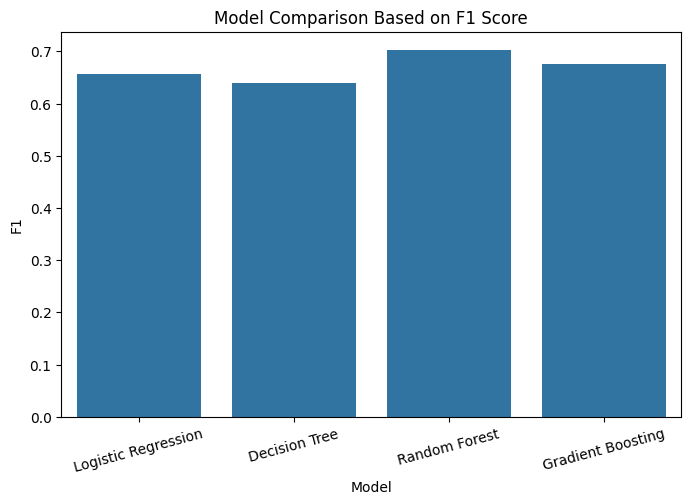

In [ ]:
# visualisasi
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='F1'
)

plt.title("Model Comparison Based on F1 Score")
plt.xticks(rotation=15)

plt.show()

In [ ]:
# Memilih model terbaik berdasarkan Macro F1 pada validation set
model_dict = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

best_model_name = results.loc[results["F1"].idxmax(), "Model"]
best_model = model_dict[best_model_name]

if best_model_name == "Gradient Boosting":
    y_pred = best_model.predict(X_test_processed.toarray())
else:
    y_pred = best_model.predict(X_test_processed)

print("Best model berdasarkan validation Macro F1:", best_model_name)


In [ ]:
# evaluasi pada test set
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Good',
            'Poor',
            'Standard'
        ]
    )
)

              precision    recall  f1-score   support

        Good       0.64      0.63      0.64       447
        Poor       0.72      0.69      0.71       723
    Standard       0.75      0.77      0.76      1330

    accuracy                           0.72      2500
   macro avg       0.70      0.70      0.70      2500
weighted avg       0.72      0.72      0.72      2500



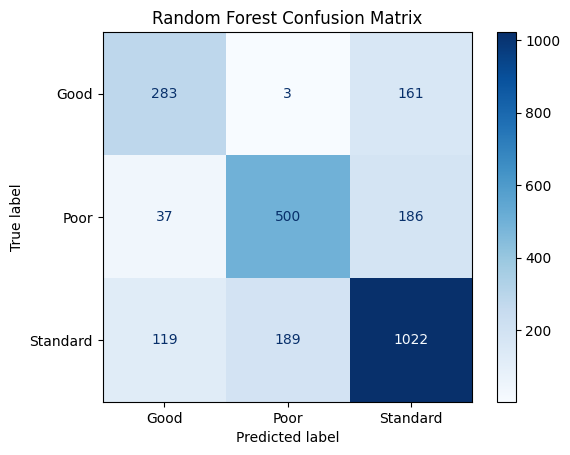

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap='Blues')

plt.title(f"{best_model_name} Confusion Matrix")

plt.show()


Confusion Matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas Credit Score. Interpretasi jumlah prediksi benar dan kesalahan klasifikasi sebaiknya didasarkan pada hasil confusion matrix yang dihasilkan setelah model terbaik dipilih berdasarkan validation Macro F1.


In [ ]:
# Feature importance / kontribusi fitur model terpilih
feature_names = (
    num +
    list(encoder.get_feature_names_out(obj))
)

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    importance_label = "Importance"
elif hasattr(best_model, "coef_"):
    importance_values = np.mean(np.abs(best_model.coef_), axis=0)
    importance_label = "Mean Absolute Coefficient"
else:
    raise AttributeError("Model terpilih tidak menyediakan feature importance atau coefficients.")

importance_df = pd.DataFrame({
    "Feature": feature_names,
    importance_label: importance_values
})

importance_df = importance_df.sort_values(
    importance_label,
    ascending=False
)

importance_df.head(10)


,Feature,Importance
11,Outstanding_Debt,0.061135
5,Interest_Rate,0.050984
7,Delay_from_due_date,0.039882
9,Changed_Credit_Limit,0.036596
10,Num_Credit_Inquiries,0.033527
4,Num_Credit_Card,0.032359
8,Num_of_Delayed_Payment,0.030196
3,Num_Bank_Accounts,0.029622
1,Annual_Income,0.029096
15,Monthly_Balance,0.028872


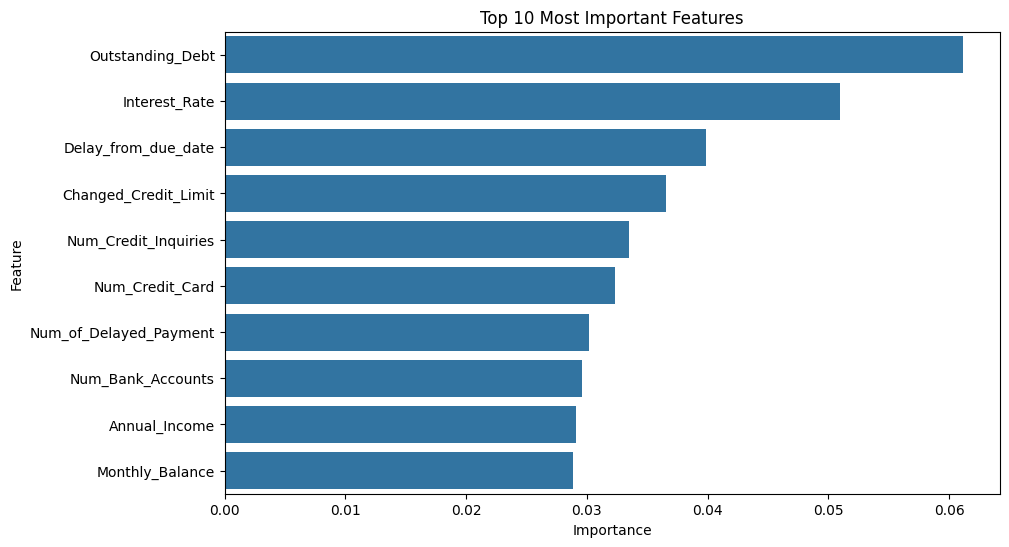

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x=importance_df.columns[1],
    y='Feature'
)

plt.title(f'Top 10 Most Important Features - {best_model_name}')

plt.show()


Berdasarkan hasil eksperimen terhadap empat algoritma machine learning, model final dipilih berdasarkan nilai Macro F1 tertinggi pada validation set. Testing set hanya digunakan sekali untuk mengevaluasi performa akhir model yang telah dipilih.

Tahap preprocessing meliputi penanganan missing value, perbaikan data yang tidak valid, encoding fitur kategorikal, serta feature scaling pada fitur numerik. Proses yang menggunakan parameter hasil pembelajaran seperti imputasi, OneHotEncoder, dan StandardScaler di-fit menggunakan data training, kemudian diterapkan pada validation dan testing set.

Hasil feature importance atau kontribusi koefisien digunakan untuk mengidentifikasi fitur yang paling berpengaruh terhadap prediksi Credit Score berdasarkan model final.


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df["Credit_Score"])

print(le.classes_)

['Good' 'Poor' 'Standard']
